# VI. order_items.csv — Chi tiết đơn hàng

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

In [3]:
order_items_df.head(15)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.00,NaN,NaN
1,2,609,7,10166.25,0.00,NaN,NaN
2,3,396,3,11220.33,0.00,NaN,NaN
3,4,635,5,10639.25,0.00,NaN,NaN
4,6,1935,1,1597.84,0.00,NaN,NaN
5,7,1934,6,1633.49,0.00,NaN,NaN
6,8,1934,6,1602.92,0.00,NaN,NaN
7,8,1935,4,1642.51,0.00,NaN,NaN
8,9,1432,8,4049.64,0.00,NaN,NaN
9,10,1431,5,3977.37,0.00,NaN,NaN


In [4]:
order_items_df.shape

(714669, 7)

In [5]:
order_items_df.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'promo_id', 'promo_id_2'],
      dtype='object')

In [6]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 38.2+ MB


**Nhận xét**: promo_id với promo_id_2 rất nhiều missing values

#### a. Missing values

In [8]:
order_items_df[['promo_id', 'promo_id_2']].isnull().sum()

promo_id      438353
promo_id_2    714463
dtype: int64

In [9]:
print("Tỷ lệ missing values trong cột 'promo_id': {:.2f}%".format(order_items_df['promo_id'].isnull().mean() * 100))
print("Tỷ lệ missing values trong cột 'promo_id_2': {:.2f}%".format(order_items_df['promo_id_2'].isnull().mean() * 100))

Tỷ lệ missing values trong cột 'promo_id': 61.34%
Tỷ lệ missing values trong cột 'promo_id_2': 99.97%


## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

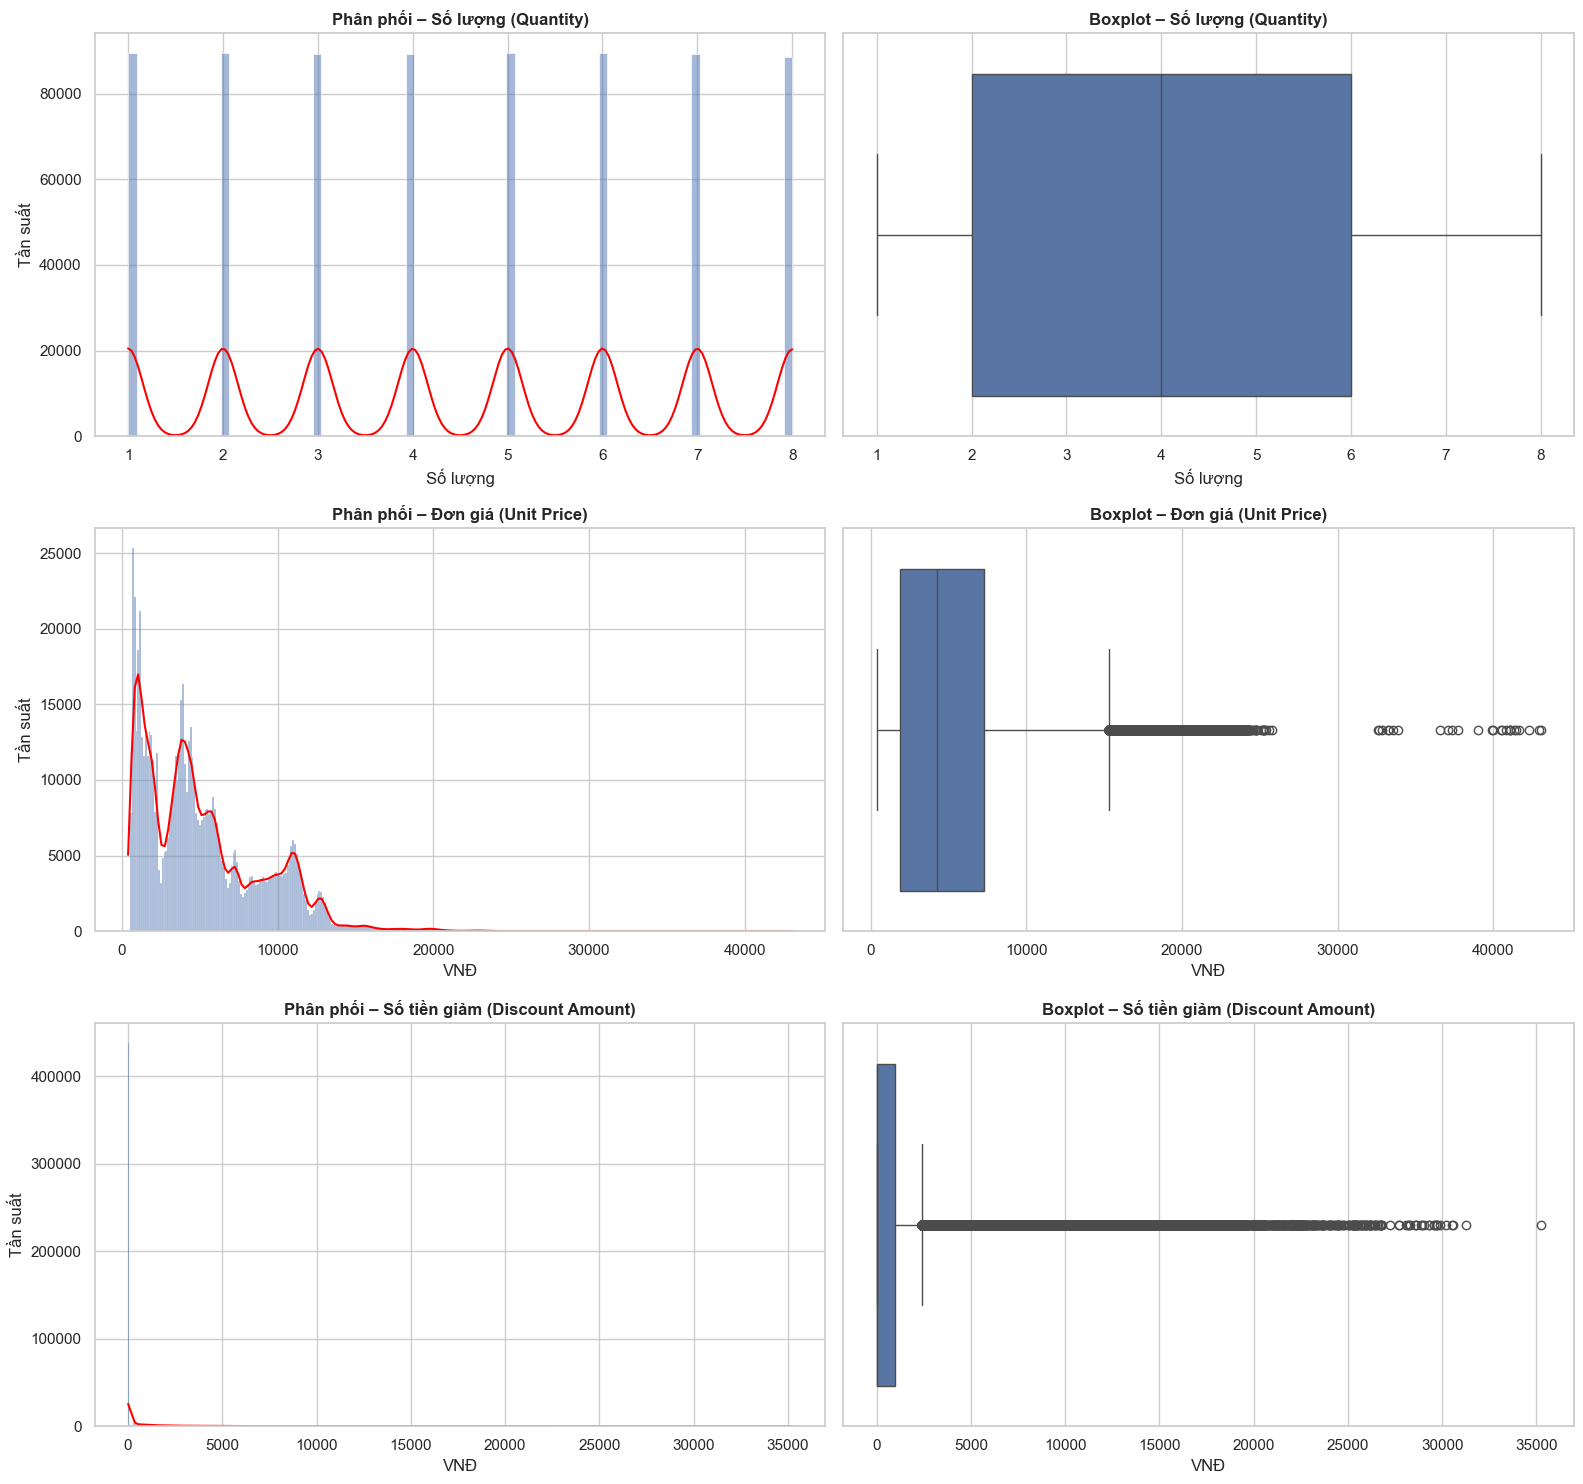

In [15]:
# Cấu hình các cột liên tục cần vẽ trong order_items
col_config = {
    'quantity': {'title': 'Số lượng (Quantity)', 'xlabel': 'Số lượng'},
    'unit_price': {'title': 'Đơn giá (Unit Price)', 'xlabel': 'VNĐ'},
    'discount_amount': {'title': 'Số tiền giảm (Discount Amount)', 'xlabel': 'VNĐ'}
}

# Hàm vẽ kết hợp Distribution và Boxplot
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(16, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        # Bắt lỗi nếu không có đường KDE
        if ax.lines:
            ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    plt.show()

# Danh sách các cột cần vẽ
con_cols_names = ['quantity', 'unit_price', 'discount_amount']
plot_distribution_boxplot(order_items_df, con_cols_names)

##### 1. Cột unit_price

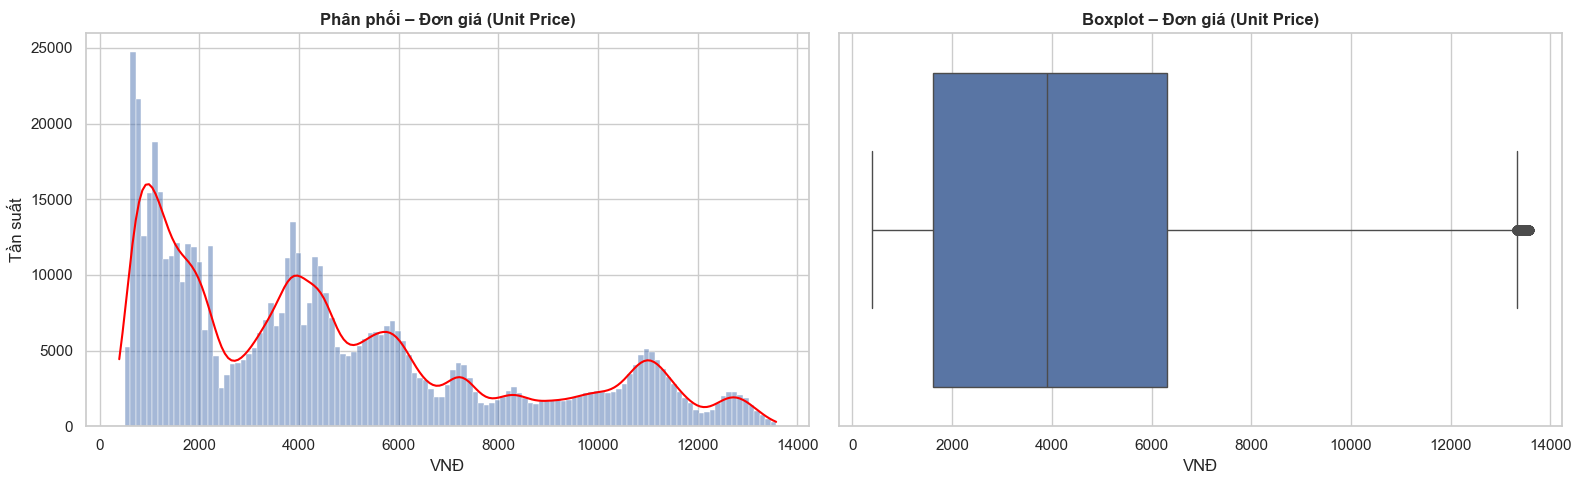

In [26]:
# Lọc outlier bằng IQR cho cột 'unit_price'
Q1 = order_items_df['unit_price'].quantile(0.25)
Q3 = order_items_df['unit_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_order_items_df = order_items_df[(order_items_df['unit_price'] >= lower_bound) & (order_items_df['unit_price'] <= upper_bound)]
plot_distribution_boxplot(filtered_order_items_df, ['unit_price'])

##### 2. Cột discount_amount

In [27]:
order_items_df['discount_amount'].value_counts(dropna=False)

discount_amount
0.00       431696
400.00       2679
50.00        2667
250.00       2653
300.00       2641
            ...  
1259.62         1
754.38          1
260.57          1
1402.59         1
1721.28         1
Name: count, Length: 107094, dtype: int64

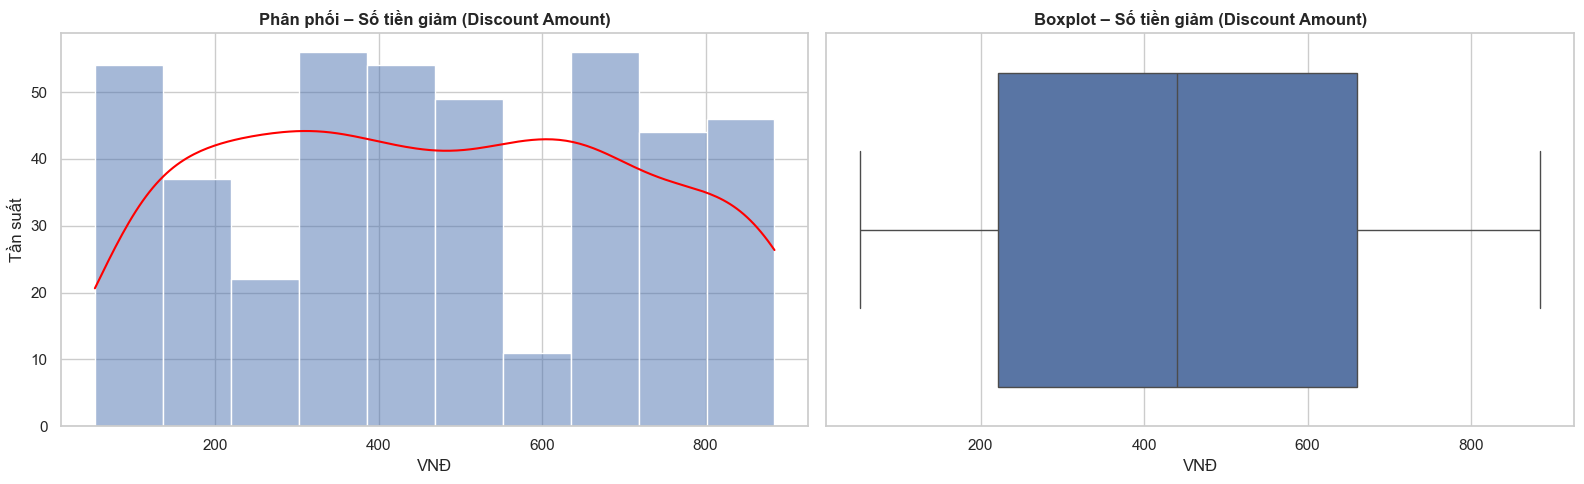

In [28]:
# Lọc outlier bằng IQR cho cột 'unit_price'
Q1 = order_items_df['discount_amount'].quantile(0.25)
Q3 = order_items_df['discount_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_order_items_df = order_items_df[(order_items_df['discount_amount'] >= lower_bound) & (order_items_df['unit_price'] <= upper_bound)]
plot_distribution_boxplot(filtered_order_items_df, ['discount_amount'])

Nhận xét: 431696 là giá trị ngoại lai có thể do nhập liệu sai nên bỏ

#### b. Thống kê mô tả 

In [14]:
order_items_df[['unit_price', 'discount_amount']].describe()

,unit_price,discount_amount
count,714669.00,714669.00
mean,5114.69,1048.89
std,3774.82,2280.53
min,392.57,0.00
25%,1906.89,0.00
50%,4257.77,0.00
75%,7273.76,967.63
max,43056.00,35235.47


**Nhận xét:**

- **Quan sát:**
    - **Số lượng (Quantity):** Dữ liệu phân bố đều tuyệt đối (uniform distribution) từ 1 đến 8 sản phẩm. Mỗi mức số lượng đều có tần suất xấp xỉ 90.000 đơn hàng. Biểu đồ Boxplot cho thấy tính đối xứng hoàn hảo với trung vị nằm ở mức 4.5.
    - **Đơn giá (Unit Price):** Phân bố lệch phải (right-skewed) với trung bình (~5.114 VNĐ) cao hơn trung vị (~4.257 VNĐ). Dữ liệu tập trung mạnh nhất ở dải dưới 10.000 VNĐ nhưng kéo dài tới tối đa 43.056 VNĐ. Boxplot ghi nhận rất nhiều giá trị ngoại lai (outliers) phía trên mốc 15.000 VNĐ.
    - **Số tiền giảm (Discount Amount):** Phân bố cực kỳ lệch phải. Hơn 50% dữ liệu có giá trị bằng 0 (không áp dụng giảm giá). Tuy nhiên, có những trường hợp ngoại lai cá biệt có số tiền giảm lên tới hơn 35.000 VNĐ, thậm chí cao hơn cả đơn giá trung bình.

- **Insights:**
    - **Hành vi mua sắm (Quantity):** Việc số lượng sản phẩm từ 1 đến 8 có tần suất bằng nhau là một hiện tượng lạ trong dữ liệu thương mại thực tế (thường khách mua 1-2 sẽ nhiều hơn). Điều này cho thấy danh mục sản phẩm có tính đa dạng cao hoặc đơn hàng thường là các gói combo/set được chuẩn hóa về số lượng.
    - **Cơ cấu giá (Unit Price):** Danh mục chủ yếu gồm các mặt hàng bình dân/giá rẻ (tập trung dải 2.000 - 7.000 VNĐ). Các sản phẩm trên 15.000 VNĐ được coi là nhóm hàng cao cấp (premium) trong tập dữ liệu này và chiếm tỷ lệ thấp nhưng tạo ra nhiều outliers.
    - **Hiệu quả khuyến mãi (Discount Amount):** Chiến lược giảm giá không áp dụng đại trà (vì trung vị bằng 0). Số tiền giảm có độ lệch chuẩn rất lớn (std = 2.280), cao gấp đôi mức giảm trung bình, cho thấy sự khác biệt cực lớn giữa các chương trình ưu đãi—có thể là sự kết hợp giữa các voucher nhỏ và các chương trình giảm sâu cực hạn cho khách hàng VIP hoặc xả hàng.
    - **Phân tích kỹ thuật:** Với biến Unit Price và Discount Amount, sự tồn tại của quá nhiều outliers và độ lệch lớn yêu cầu phải thực hiện chuẩn hóa dữ liệu (như RobustScaler hoặc Log Transformation) trước khi đưa vào các mô hình học máy để tránh làm sai lệch kết quả dự báo.

- **Gợi ý hành động:**
    - **Phân nhóm khách hàng (Customer Segmentation):** Sử dụng biến Quantity và Unit Price để phân loại nhóm khách hàng "mua lẻ giá trị thấp" và "mua sỉ/combo giá trị cao" nhằm áp dụng các chính sách chăm sóc riêng biệt.
    - **Tối ưu hóa chính sách giảm giá:** Kiểm tra lại các Outliers của Discount Amount (mức giảm > 15.000 VNĐ). Nếu các đơn hàng này có Unit Price thấp, cần rà soát lại để tránh tình trạng "giảm giá âm" (số tiền giảm lớn hơn lợi nhuận gộp).
    - **Chiến lược giá theo số lượng:** Vì tần suất mua từ 1-8 là như nhau, doanh nghiệp có thể thử nghiệm chính sách "mua nhiều giảm sâu" (Volume Discount) cho các mốc từ 5 sản phẩm trở lên để kiểm tra xem có thể đẩy tần suất các mốc này lên cao hơn nữa nhằm tăng doanh thu tổng (Revenue).

### 1.1.2. Biến phân loại (Categorical)

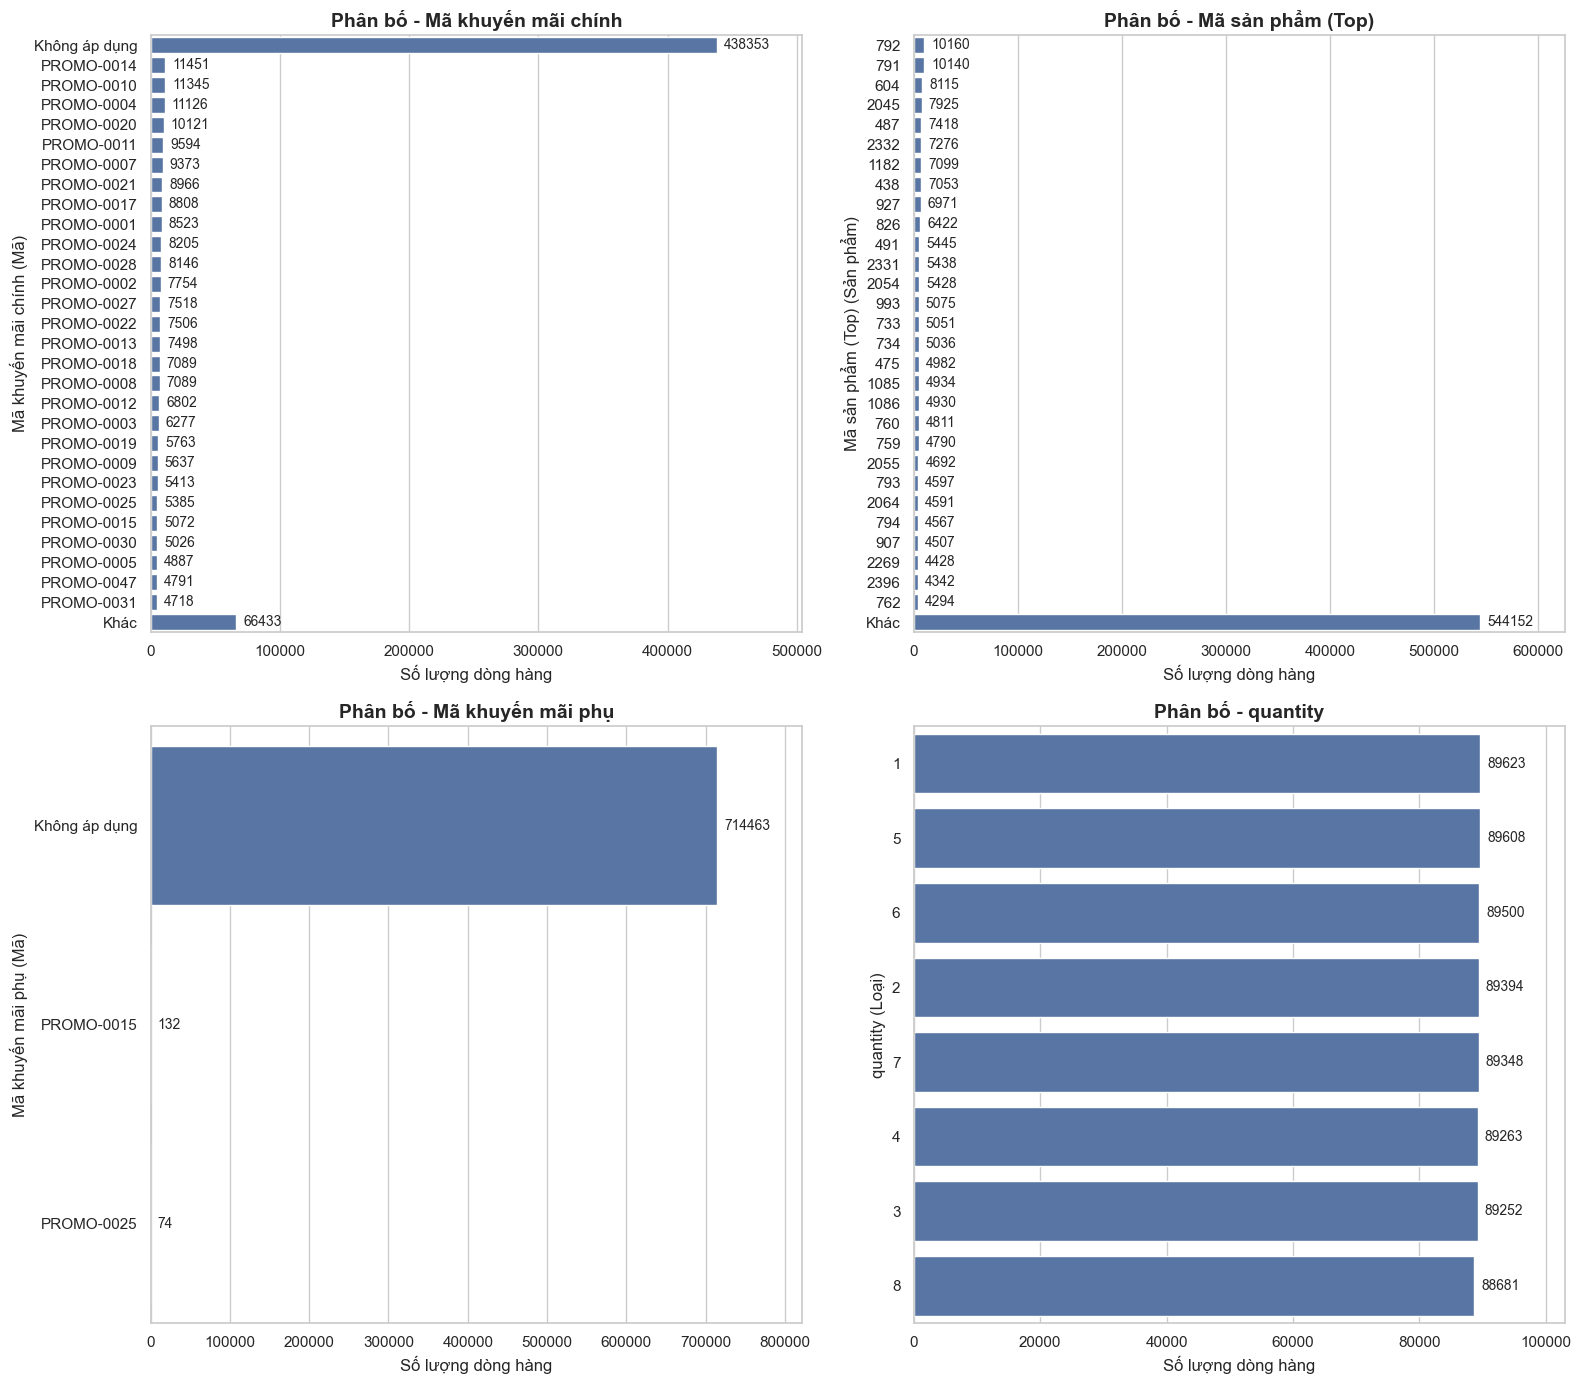

In [19]:
COL_INFO = {
    'promo_id': {'name': 'Mã khuyến mãi chính', 'unit': 'Mã'},
    'promo_id_2': {'name': 'Mã khuyến mãi phụ', 'unit': 'Mã'},
    'product_id': {'name': 'Mã sản phẩm (Top)', 'unit': 'Sản phẩm'}
}

# 2. Hàm vẽ biểu đồ phân bố Categorical (Bar chart ngang)
def plot_horizontal_bar_chart(df, cate_cols_names):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    # Thiết lập kích thước: Tăng chiều ngang để có không gian cho số liệu
    fig, axes = plt.subplots(rows, cols, figsize=(16, 7 * rows)) 
    
    # Xử lý trường hợp chỉ có 1 biểu đồ
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]
        
        if col_name in df.columns:
            # Lấy tần suất xuất hiện, điền 'Không áp dụng' cho các giá trị bị thiếu (NaN)
            val_counts = df[col_name].fillna('Không áp dụng').value_counts()
            
            # Xử lý: Lấy top 30 theo yêu cầu của bạn
            TOP = 30
            if len(val_counts) > TOP:
                top_data = val_counts.iloc[:(TOP - 1)]
                other_sum = val_counts.iloc[(TOP - 1):].sum()
                plot_data = pd.concat([top_data, pd.Series({'Khác': other_sum})])
            else:
                plot_data = val_counts
                
            # Đảm bảo index là kiểu chuỗi
            plot_data.index = plot_data.index.astype(str)
            
            # Vẽ Bar chart ngang
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)
            
            # Lấy thông tin Tên và Đơn vị từ Từ điển
            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'Loại'}) 
            
            # Cài đặt tiêu đề và nhãn
            ax.set_title(f"Phân bố - {info['name']}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Số lượng dòng hàng", fontsize=12)
            ax.set_ylabel(f"{info['name']} ({info['unit']})", fontsize=12)
            
            # Thêm con số thực tế bên phải mỗi thanh bar
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f'{int(width)}', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=10, 
                                xytext=(5, 0), textcoords='offset points')
            
            # Mở rộng giới hạn trục x thêm 15% để số liệu không bị che
            ax.set_xlim(0, max(plot_data.values) * 1.15)
            
        else:
            ax.set_visible(False)
            
    # Ẩn các trục không sử dụng
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# 3. Chạy hàm với các cột từ order_items.csv
# 'product_id' được thêm vào để bạn có thể thấy top sản phẩm bán chạy nhất
cate_cols = ['promo_id', 'product_id', 'promo_id_2', 'quantity']
plot_horizontal_bar_chart(order_items_df, cate_cols)

#### a. Cột promo_id

In [23]:
order_items_df['promo_id'].unique()

array([nan, 'PROMO-0006', 'PROMO-0001', 'PROMO-0002', 'PROMO-0005',
       'PROMO-0003', 'PROMO-0004', 'PROMO-0007', 'PROMO-0008',
       'PROMO-0009', 'PROMO-0010', 'PROMO-0016', 'PROMO-0011',
       'PROMO-0012', 'PROMO-0015', 'PROMO-0013', 'PROMO-0014',
       'PROMO-0017', 'PROMO-0018', 'PROMO-0019', 'PROMO-0020',
       'PROMO-0026', 'PROMO-0021', 'PROMO-0022', 'PROMO-0025',
       'PROMO-0023', 'PROMO-0024', 'PROMO-0027', 'PROMO-0028',
       'PROMO-0029', 'PROMO-0030', 'PROMO-0036', 'PROMO-0031',
       'PROMO-0032', 'PROMO-0035', 'PROMO-0033', 'PROMO-0034',
       'PROMO-0037', 'PROMO-0038', 'PROMO-0039', 'PROMO-0040',
       'PROMO-0046', 'PROMO-0041', 'PROMO-0042', 'PROMO-0045',
       'PROMO-0043', 'PROMO-0044', 'PROMO-0047', 'PROMO-0048',
       'PROMO-0049', 'PROMO-0050'], dtype=object)

In [21]:
order_items_df['promo_id'].value_counts(dropna=False)

promo_id
NaN           438353
PROMO-0014     11451
PROMO-0010     11345
PROMO-0004     11126
PROMO-0020     10121
PROMO-0011      9594
PROMO-0007      9373
PROMO-0021      8966
PROMO-0017      8808
PROMO-0001      8523
PROMO-0024      8205
PROMO-0028      8146
PROMO-0002      7754
PROMO-0027      7518
PROMO-0022      7506
PROMO-0013      7498
PROMO-0018      7089
PROMO-0008      7089
PROMO-0012      6802
PROMO-0003      6277
PROMO-0019      5763
PROMO-0009      5637
PROMO-0023      5413
PROMO-0025      5385
PROMO-0015      5072
PROMO-0030      5026
PROMO-0005      4887
PROMO-0047      4791
PROMO-0031      4718
PROMO-0037      4661
PROMO-0041      4639
PROMO-0029      4328
PROMO-0034      4277
PROMO-0032      3867
PROMO-0050      3500
PROMO-0044      3462
PROMO-0040      3286
PROMO-0035      3174
PROMO-0033      3101
PROMO-0048      3091
PROMO-0038      3074
PROMO-0042      2999
PROMO-0006      2828
PROMO-0039      2593
PROMO-0049      2568
PROMO-0016      2526
PROMO-0043      2476
PROM

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table